In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification,make_regression

In [2]:
x,y= make_regression(n_features=1,bias=5,noise=20,n_samples=500)
X = np.hstack([x,y.reshape(-1,1)])
X[:,1] = 3*X[:,1]

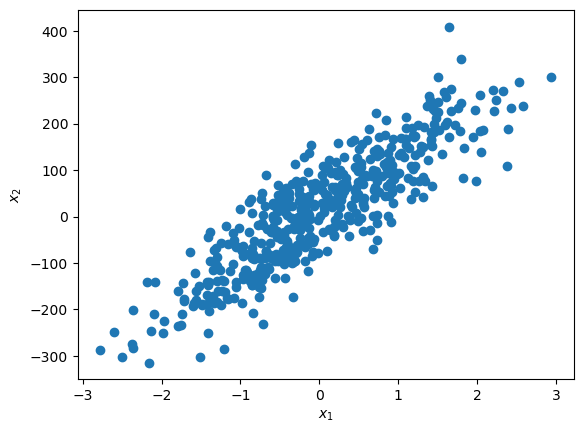

In [3]:

plt.scatter(*X.T)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.show()




In [4]:
m = np.mean(X,0)
s = np.std(X,0)
Xm = X.copy()
Xms = X.copy()
for i in range(len(m)):
    Xm[:,i] = Xm[:,i] - m[i]
    Xms[:,i] = (Xms[:,i] - m[i])/s[i]

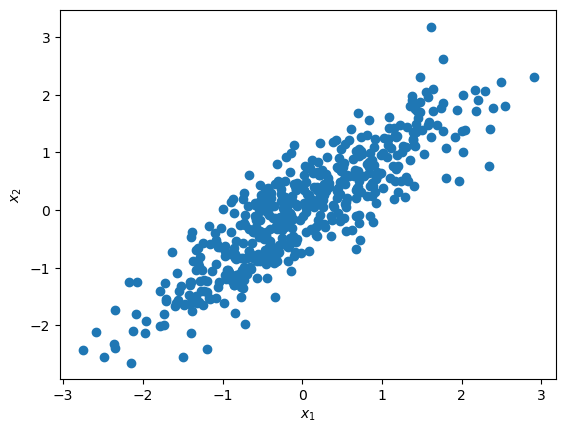

In [5]:
plt.scatter(*Xms.T)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.show()


# Resuelto con numpy

## Matriz de covarianza

In [6]:
Cx = Xms.T @ Xms / (Xms.shape[0]-1)
print("Matriz de covarianza:")
print(Cx)

Matriz de covarianza:
[[1.00200401 0.88009372]
 [0.88009372 1.00200401]]


## Cálculo de autovalores y autovectores

In [7]:
eigvals, eigvecs = np.linalg.eig(Cx)

asort = eigvals.argsort()[::-1]
eigvals = eigvals[asort]
P = eigvecs[:,asort]

print("Autovalores:",eigvals)
print("Matriz de autovectores:")
print(P)

Autovalores: [1.88209773 0.12191029]
Matriz de autovectores:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


## Proyección de los datos

In [8]:
Y = Xms @ P


Text(0, 0.5, '$y_2$')

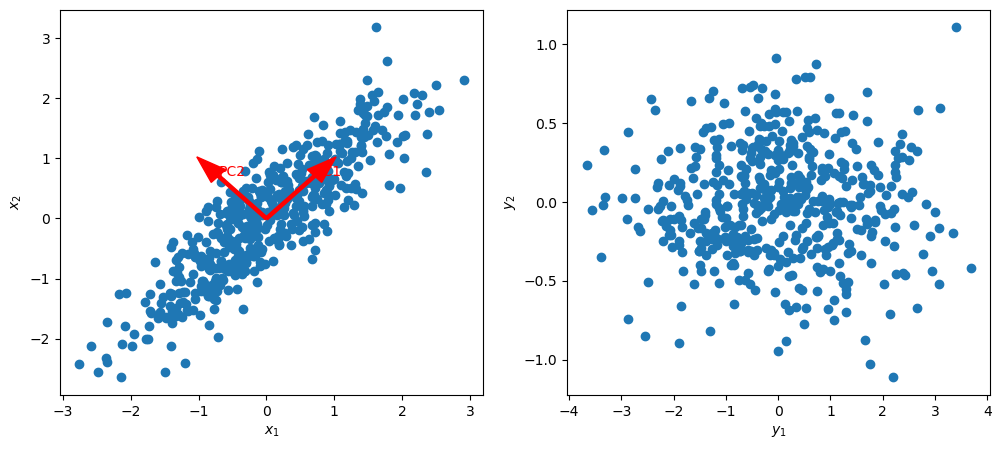

In [9]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.scatter(*Xms.T)

origin = np.mean(Xms, axis=0)
for i in range(2):
    vec = eigvecs[:, i]
    plt.arrow(origin[0], origin[1], vec[0], vec[1], 
              color='red', width=0.05, head_width=0.3, label=f'PC{i+1}')
    plt.text(origin[0] + vec[0], origin[1] + vec[1], f"PC{i+1}", color='red')
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")

plt.subplot(122)
plt.scatter(*Y.T)
plt.xlabel(r"$y_1$")
plt.ylabel(r"$y_2$")

#### Comprobación de que la matriz de covarianza debe ser diagonal e igual a los autovalores

In [10]:
print("Autovectores:",eigvals)
print("Covarianza de las variables transformadas:")
Y.T @ Y / (Y.shape[0]-1)

Autovectores: [1.88209773 0.12191029]
Covarianza de las variables transformadas:


array([[ 1.88209773e+00, -1.50180469e-17],
       [-1.50180469e-17,  1.21910286e-01]])

# Resuelto con sklearn

In [11]:
pca = PCA().fit(Xms)


In [12]:
# autovalores
pca.explained_variance_

array([1.88209773, 0.12191029])

In [13]:
# matriz de cambio de base
pca.components_.T

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

Text(0, 0.5, '$y_2$')

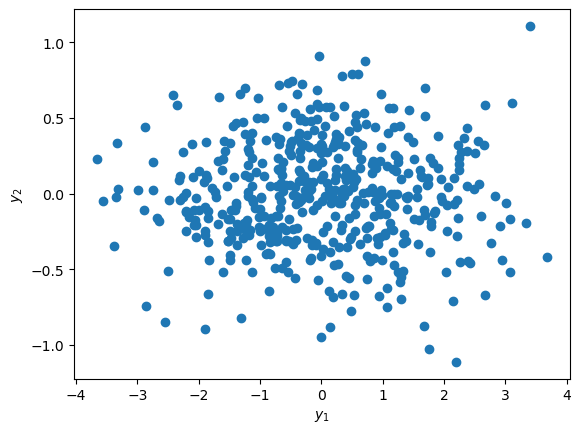

In [14]:
Y = pca.transform(Xms)
plt.scatter(*Y.T)
plt.xlabel(r"$y_1$")
plt.ylabel(r"$y_2$")